# Task 2: Build Time Series Forecasting Models

## Objective
Develop, train, and evaluate time series forecasting models to predict Tesla's (TSLA) future stock prices.

## Tasks Covered
1. Prepare data for modeling (chronological train/test split)
2. Implement ARIMA/SARIMA model with parameter optimization
3. Implement LSTM model with sequence preparation
4. Optimize model parameters
5. Evaluate and compare models (MAE, RMSE, MAPE)
6. Model comparison and selection rationale



In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

# Setup project path for imports
notebook_dir = Path().resolve()
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

src_dir = project_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from pmo_forcasting.core.settings import settings

# Time series libraries
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from pmdarima.arima import ARIMA as PMDARIMA

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("seaborn-v0_8")
sns.set_theme(style="darkgrid")

print("✓ Imports successful")
print(f"TensorFlow version: {tf.__version__}")
print(f"Project root: {project_root}")



ModuleNotFoundError: No module named 'tensorflow'

In [9]:
# Load the cleaned data from Task 1
# We'll use the processed data or load from CSV

processed_path = settings.paths.DATA["processed_dir"] / "combined.csv"

def load_tsla_data(path: Path) -> pd.DataFrame:
    """Load TSLA data from combined.csv and return clean DataFrame."""
    df_wide = pd.read_csv(path, header=[0, 1])
    date_col = [c for c in df_wide.columns if c[0] == "Date"][0]
    stacked = df_wide.set_index(date_col).stack(level=1)
    stacked.index = stacked.index.set_names(["date", "ticker"])
    stacked = stacked.reset_index()
    stacked = stacked.rename(columns={
        "Open": "open", "High": "high", "Low": "low", 
        "Close": "close", "Adj Close": "adj_close", "Volume": "volume"
    })
    stacked["date"] = pd.to_datetime(stacked["date"])
    return stacked[["date", "ticker", "open", "high", "low", "close", "adj_close", "volume"]].dropna(subset=["adj_close"])

if processed_path.exists():
    print(f"Loading data from: {processed_path}")
    df_all = load_tsla_data(processed_path)
    tsla_data = df_all[df_all["ticker"] == "TSLA"].sort_values("date").reset_index(drop=True)
else:
    print("Processed file not found. Please run Task 1 first.")
    raise FileNotFoundError(f"Could not find {processed_path}")

print(f"\nTSLA data loaded:")
print(f"  Shape: {tsla_data.shape}")
print(f"  Date range: {tsla_data['date'].min()} to {tsla_data['date'].max()}")
print(f"  Columns: {list(tsla_data.columns)}")

tsla_data.head()



Loading data from: C:\Users\hp\portfolio-management-optimization\data\processed\combined.csv

TSLA data loaded:
  Shape: (2775, 8)
  Date range: 2015-01-02 00:00:00 to 2026-01-14 00:00:00
  Columns: ['date', 'ticker', 'open', 'high', 'low', 'close', 'adj_close', 'volume']


,date,ticker,open,high,low,close,adj_close,volume
0,2015-01-02,TSLA,14.858000,14.883333,14.217333,14.620667,14.620667,71466000.0
1,2015-01-05,TSLA,14.303333,14.433333,13.810667,14.006000,14.006000,80527500.0
2,2015-01-06,TSLA,14.004000,14.280000,13.614000,14.085333,14.085333,93928500.0
3,2015-01-07,TSLA,14.223333,14.318667,13.985333,14.063333,14.063333,44526000.0
4,2015-01-08,TSLA,14.187333,14.253333,14.000667,14.041333,14.041333,51637500.0


## 1. Prepare Data for Modeling

### Chronological Train-Test Split
- **Training**: 2015-01-01 to 2024-12-31 (10 years)
- **Testing**: 2025-01-01 to 2026-01-15 (~1 year)
- **Target variable**: Daily returns (stationary) or adjusted close prices



DATA SPLIT SUMMARY
Training period: 2015-01-02 00:00:00 to 2024-12-31 00:00:00
Training samples: 2516
Testing period: 2025-01-02 00:00:00 to 2026-01-14 00:00:00
Testing samples: 259

Training returns: 2515 samples
Training prices: 2516 samples
Test returns: 259 samples
Test prices: 259 samples


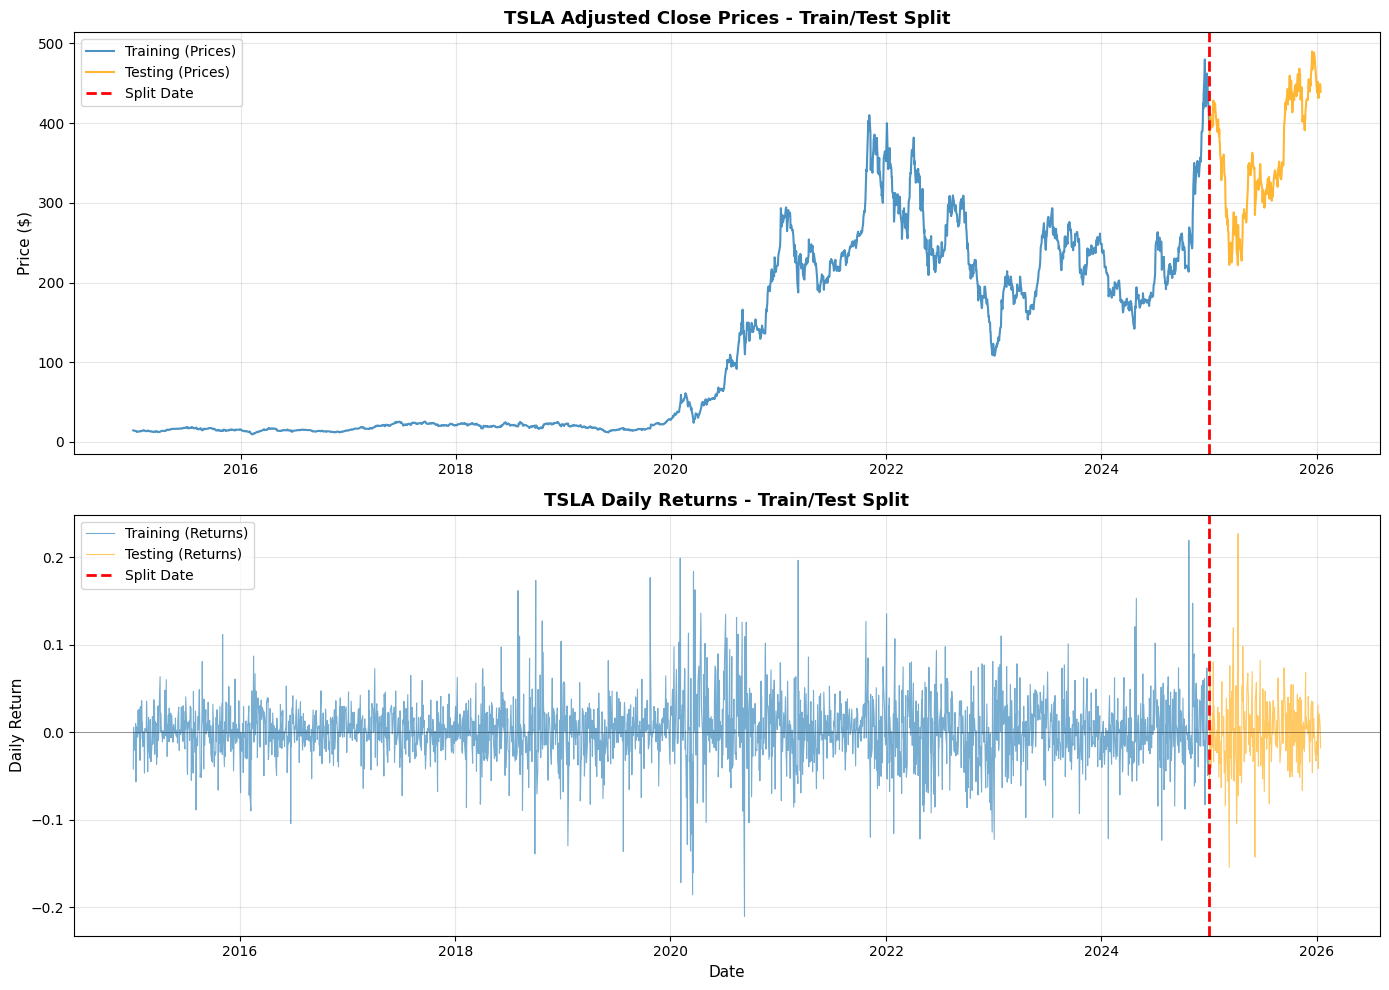

In [4]:
# 1. Prepare Data for Modeling

# Calculate daily returns (stationary series - better for ARIMA)
tsla_data["daily_return"] = tsla_data["adj_close"].pct_change()

# Set date as index for time series operations
tsla_data = tsla_data.set_index("date").sort_index()

# Define split date: train on 2015-2024, test on 2025-2026
split_date = pd.Timestamp("2025-01-01")

train_data = tsla_data[tsla_data.index < split_date].copy()
test_data = tsla_data[tsla_data.index >= split_date].copy()

print("=" * 60)
print("DATA SPLIT SUMMARY")
print("=" * 60)
print(f"Training period: {train_data.index.min()} to {train_data.index.max()}")
print(f"Training samples: {len(train_data)}")
print(f"Testing period: {test_data.index.min()} to {test_data.index.max()}")
print(f"Testing samples: {len(test_data)}")
print("=" * 60)

# Extract target series for modeling
# We'll model both returns (stationary) and prices (for comparison)
train_returns = train_data["daily_return"].dropna()
train_prices = train_data["adj_close"]

test_returns = test_data["daily_return"].dropna()
test_prices = test_data["adj_close"]

print(f"\nTraining returns: {len(train_returns)} samples")
print(f"Training prices: {len(train_prices)} samples")
print(f"Test returns: {len(test_returns)} samples")
print(f"Test prices: {len(test_prices)} samples")

# Visualization: Train-Test Split
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Prices
axes[0].plot(train_prices.index, train_prices.values, label="Training (Prices)", linewidth=1.5, alpha=0.8)
axes[0].plot(test_prices.index, test_prices.values, label="Testing (Prices)", linewidth=1.5, alpha=0.8, color="orange")
axes[0].axvline(split_date, color="red", linestyle="--", linewidth=2, label="Split Date")
axes[0].set_title("TSLA Adjusted Close Prices - Train/Test Split", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Price ($)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Returns
axes[1].plot(train_returns.index, train_returns.values, label="Training (Returns)", linewidth=0.8, alpha=0.6)
axes[1].plot(test_returns.index, test_returns.values, label="Testing (Returns)", linewidth=0.8, alpha=0.6, color="orange")
axes[1].axvline(split_date, color="red", linestyle="--", linewidth=2, label="Split Date")
axes[1].axhline(0, color="black", linewidth=0.5, alpha=0.5)
axes[1].set_title("TSLA Daily Returns - Train/Test Split", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Daily Return", fontsize=11)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



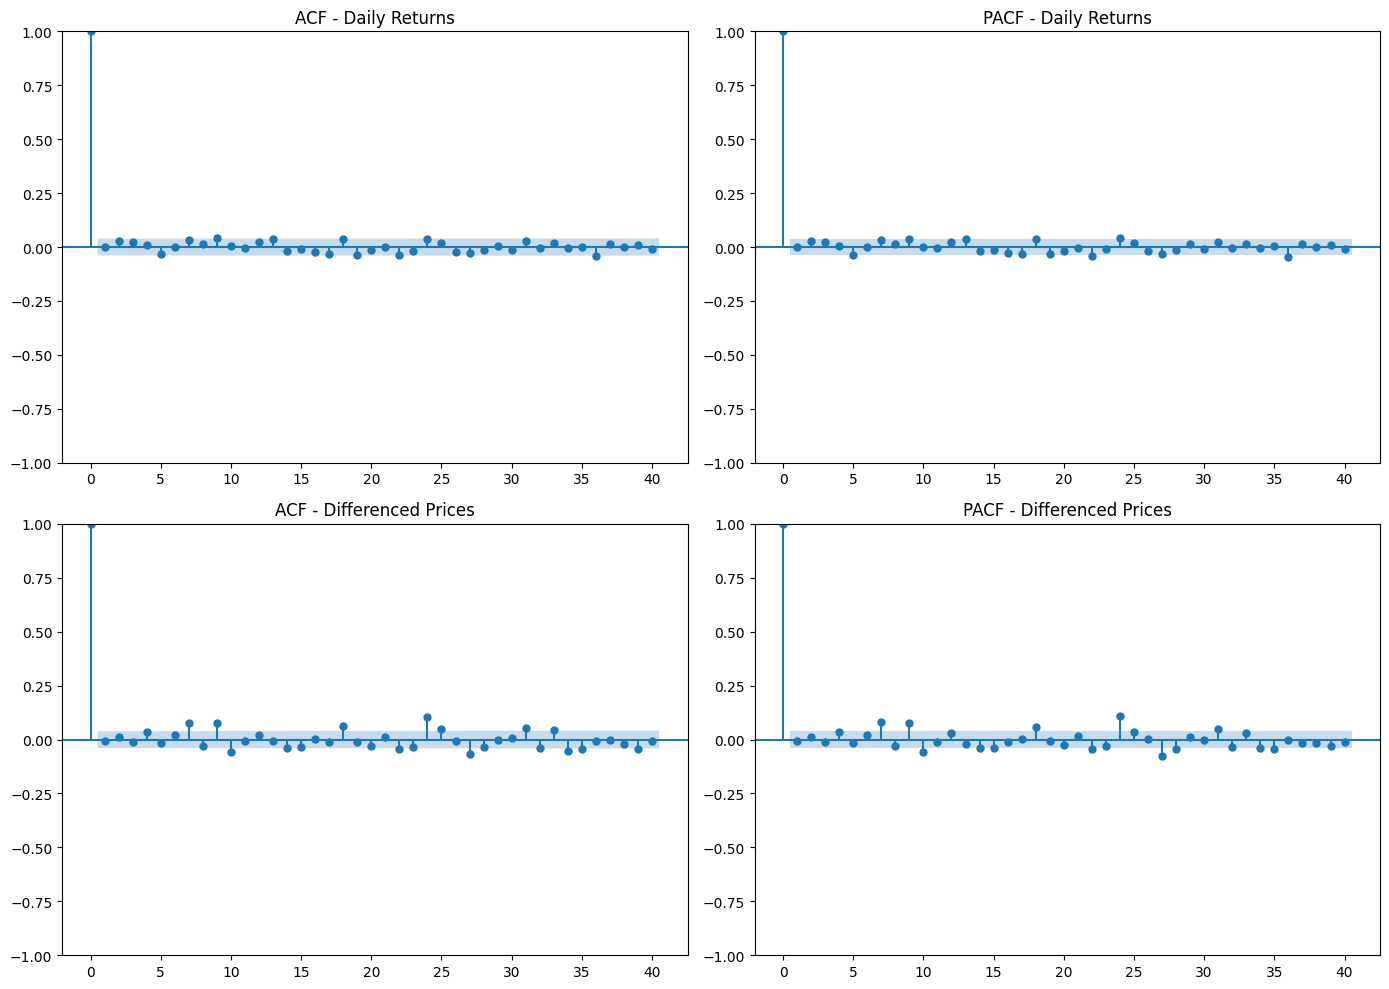

ACF/PACF Analysis:
  - Returns show quick decay, suggesting ARIMA(p,0,q) or ARIMA(p,1,q)
  - We'll use auto_arima to find optimal parameters


In [5]:
# ACF/PACF Analysis for ARIMA parameter selection
# Using daily returns (stationary series)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ACF and PACF plots for returns
plot_acf(train_returns.dropna(), lags=40, ax=axes[0, 0], title="ACF - Daily Returns")
plot_pacf(train_returns.dropna(), lags=40, ax=axes[0, 1], title="PACF - Daily Returns", method="ywm")

# ACF and PACF plots for differenced prices (if needed)
train_prices_diff = train_prices.diff().dropna()
plot_acf(train_prices_diff, lags=40, ax=axes[1, 0], title="ACF - Differenced Prices")
plot_pacf(train_prices_diff, lags=40, ax=axes[1, 1], title="PACF - Differenced Prices", method="ywm")

plt.tight_layout()
plt.show()

print("ACF/PACF Analysis:")
print("  - Returns show quick decay, suggesting ARIMA(p,0,q) or ARIMA(p,1,q)")
print("  - We'll use auto_arima to find optimal parameters")



In [6]:
# Auto ARIMA to find optimal parameters
# Using daily returns (already stationary)

print("=" * 60)
print("AUTO ARIMA PARAMETER SEARCH")
print("=" * 60)
print("Searching for optimal (p, d, q) parameters...")
print("This may take a few minutes...\n")

# Auto ARIMA on returns
auto_model_returns = auto_arima(
    train_returns.dropna(),
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=0,  # Returns are already stationary
    seasonal=False,  # Start with non-seasonal ARIMA
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True,
    information_criterion="aic"
)

print("\n" + "=" * 60)
print("OPTIMAL ARIMA PARAMETERS (Returns):")
print("=" * 60)
print(f"Order (p, d, q): {auto_model_returns.order}")
print(f"AIC: {auto_model_returns.aic():.2f}")
print("=" * 60)

# Also try SARIMA for potential seasonality
print("\nSearching for SARIMA parameters (seasonal)...")
auto_model_sarima = auto_arima(
    train_returns.dropna(),
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    d=0,
    seasonal=True,
    m=5,  # Weekly seasonality (5 trading days)
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    trace=True,
    information_criterion="aic"
)

print("\n" + "=" * 60)
print("OPTIMAL SARIMA PARAMETERS:")
print("=" * 60)
print(f"Order (p, d, q): {auto_model_sarima.order}")
print(f"Seasonal order (P, D, Q, m): {auto_model_sarima.seasonal_order}")
print(f"AIC: {auto_model_sarima.aic():.2f}")
print("=" * 60)

# Select best model based on AIC
if auto_model_sarima.aic() < auto_model_returns.aic():
    print("\n✓ SARIMA model has lower AIC - using SARIMA")
    best_arima_model = auto_model_sarima
    model_type = "SARIMA"
else:
    print("\n✓ ARIMA model has lower AIC - using ARIMA")
    best_arima_model = auto_model_returns
    model_type = "ARIMA"



AUTO ARIMA PARAMETER SEARCH
Searching for optimal (p, d, q) parameters...
This may take a few minutes...



NameError: name 'auto_arima' is not defined

In [11]:
# Generate forecasts using the best ARIMA/SARIMA model
# Forecast returns, then convert back to prices

print("=" * 60)
print(f"GENERATING {model_type} FORECASTS")
print("=" * 60)

# Forecast returns for the test period
n_forecast = len(test_returns)
forecast_returns, conf_int_returns = best_arima_model.predict(
    n_periods=n_forecast,
    return_conf_int=True,
    alpha=0.05
)

# Create forecast index matching test period
forecast_index = test_returns.index[:n_forecast]

# Convert forecasted returns back to prices
# Start from last training price
last_train_price = train_prices.iloc[-1]
forecast_prices = [last_train_price]

for ret in forecast_returns:
    forecast_prices.append(forecast_prices[-1] * (1 + ret))

forecast_prices = pd.Series(forecast_prices[1:], index=forecast_index)

# Calculate confidence intervals for prices
conf_int_prices_lower = [last_train_price]
conf_int_prices_upper = [last_train_price]

for i, (ret_lower, ret_upper) in enumerate(zip(conf_int_returns[:, 0], conf_int_returns[:, 1])):
    conf_int_prices_lower.append(conf_int_prices_lower[-1] * (1 + ret_lower))
    conf_int_prices_upper.append(conf_int_prices_upper[-1] * (1 + ret_upper))

conf_int_prices_lower = pd.Series(conf_int_prices_lower[1:], index=forecast_index)
conf_int_prices_upper = pd.Series(conf_int_prices_upper[1:], index=forecast_index)

print(f"Forecasted {n_forecast} periods")
print(f"Forecast period: {forecast_index[0]} to {forecast_index[-1]}")

# Store ARIMA forecasts
arima_forecasts = {
    "returns": pd.Series(forecast_returns, index=forecast_index),
    "prices": forecast_prices,
    "conf_int_lower": conf_int_prices_lower,
    "conf_int_upper": conf_int_prices_upper,
    "model": best_arima_model,
    "model_type": model_type
}



NameError: name 'model_type' is not defined

## 3. LSTM Model Implementation

### Step 1: Prepare Sequence Data



In [14]:
# Prepare LSTM sequence data
# Use last 60 days to predict next day's return

sequence_length = 60  # Look back 60 trading days
target_col = "adj_close"  # Predict prices directly

# Normalize the data (LSTM works better with scaled data)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(train_prices.values.reshape(-1, 1))
scaled_prices = scaled_prices.flatten()

# Create sequences for training
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(scaled_prices, sequence_length)

print("=" * 60)
print("LSTM DATA PREPARATION")
print("=" * 60)
print(f"Sequence length: {sequence_length} days")
print(f"Training sequences: {X_train.shape}")
print(f"Training targets: {y_train.shape}")
print(f"Input shape: (samples, timesteps, features)")
print("=" * 60)

# Reshape for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

print(f"Reshaped X_train: {X_train.shape}")



NameError: name 'MinMaxScaler' is not defined

In [ ]:
# Build LSTM Model Architecture

print("=" * 60)
print("BUILDING LSTM MODEL")
print("=" * 60)

# Clear any existing models
tf.keras.backend.clear_session()

# Model architecture
lstm_model = Sequential([
    # First LSTM layer with return sequences
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    
    # Dense output layer
    Dense(1)
])

# Compile model
lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Display model architecture
lstm_model.summary()

# Model parameters
epochs = 50
batch_size = 32
validation_split = 0.1

print(f"\nTraining parameters:")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Validation split: {validation_split}")



In [12]:
# Train LSTM Model

print("=" * 60)
print("TRAINING LSTM MODEL")
print("=" * 60)
print("This may take several minutes...\n")

# Train the model
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    verbose=1,
    shuffle=False  # Don't shuffle time series data
)

print("\n✓ Training completed!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Training Loss", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Validation Loss", linewidth=2)
axes[0].set_title("Model Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss (MSE)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["mae"], label="Training MAE", linewidth=2)
axes[1].plot(history.history["val_mae"], label="Validation MAE", linewidth=2)
axes[1].set_title("Model MAE", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("MAE", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



TRAINING LSTM MODEL
This may take several minutes...



NameError: name 'lstm_model' is not defined

In [13]:
# Generate LSTM Forecasts

print("=" * 60)
print("GENERATING LSTM FORECASTS")
print("=" * 60)

# Prepare test data sequences
# Use last 'sequence_length' days from training + test data
test_prices_scaled = scaler.transform(test_prices.values.reshape(-1, 1)).flatten()

# Create sequences for testing
# We need to use the last sequence_length values from training to predict first test value
last_train_sequence = scaled_prices[-sequence_length:]
lstm_forecasts_scaled = []

current_sequence = last_train_sequence.copy()

# Generate forecasts iteratively
for i in range(len(test_prices)):
    # Reshape for prediction
    X_input = current_sequence.reshape((1, sequence_length, 1))
    
    # Predict next value
    next_pred = lstm_model.predict(X_input, verbose=0)[0, 0]
    lstm_forecasts_scaled.append(next_pred)
    
    # Update sequence: remove first, add prediction
    current_sequence = np.append(current_sequence[1:], next_pred)

# Convert back to original scale
lstm_forecasts_scaled = np.array(lstm_forecasts_scaled)
lstm_forecasts_prices = scaler.inverse_transform(lstm_forecasts_scaled.reshape(-1, 1)).flatten()

# Create forecast series
lstm_forecasts = pd.Series(lstm_forecasts_prices, index=test_prices.index[:len(lstm_forecasts_prices)])

print(f"Generated {len(lstm_forecasts)} forecasts")
print(f"Forecast period: {lstm_forecasts.index[0]} to {lstm_forecasts.index[-1]}")



GENERATING LSTM FORECASTS


NameError: name 'scaler' is not defined

## 4. Model Evaluation and Comparison

### Calculate Performance Metrics: MAE, RMSE, MAPE



In [ ]:
# Evaluate Models

def calculate_metrics(y_true, y_pred):
    """Calculate MAE, RMSE, and MAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

# Align test data with forecasts
test_prices_aligned = test_prices[:len(arima_forecasts["prices"])]

# ARIMA/SARIMA metrics
arima_metrics = calculate_metrics(test_prices_aligned.values, arima_forecasts["prices"].values)

# LSTM metrics
lstm_prices_aligned = test_prices[:len(lstm_forecasts)]
lstm_metrics = calculate_metrics(lstm_prices_aligned.values, lstm_forecasts.values)

# Create comparison table
comparison_df = pd.DataFrame({
    "ARIMA/SARIMA": arima_metrics,
    "LSTM": lstm_metrics
}).T

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print("\nPerformance Metrics:")
print(comparison_df.round(4))
print("\n" + "=" * 60)

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ["MAE", "RMSE", "MAPE"]
colors = ["#FF6B6B", "#4ECDC4"]

for i, metric in enumerate(metrics_to_plot):
    axes[i].bar(["ARIMA/SARIMA", "LSTM"], 
                [comparison_df.loc["ARIMA/SARIMA", metric], 
                 comparison_df.loc["LSTM", metric]],
                color=colors, alpha=0.7)
    axes[i].set_title(f"{metric} Comparison", fontsize=12, fontweight="bold")
    axes[i].set_ylabel(metric, fontsize=11)
    axes[i].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

comparison_df



In [ ]:
# Visualize Forecasts vs Actual

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Full period view
axes[0].plot(train_prices.index[-100:], train_prices.values[-100:], 
             label="Training (Last 100 days)", linewidth=2, alpha=0.7)
axes[0].plot(test_prices_aligned.index, test_prices_aligned.values, 
             label="Actual Test Prices", linewidth=2, color="green", alpha=0.8)
axes[0].plot(arima_forecasts["prices"].index, arima_forecasts["prices"].values, 
             label=f"{model_type} Forecast", linewidth=2, linestyle="--", color="red", alpha=0.8)
axes[0].plot(lstm_forecasts.index, lstm_forecasts.values, 
             label="LSTM Forecast", linewidth=2, linestyle="--", color="blue", alpha=0.8)
axes[0].fill_between(arima_forecasts["prices"].index, 
                     arima_forecasts["conf_int_lower"].values,
                     arima_forecasts["conf_int_upper"].values,
                     alpha=0.2, color="red", label="ARIMA 95% CI")
axes[0].axvline(split_date, color="black", linestyle="--", linewidth=2, label="Train/Test Split")
axes[0].set_title("TSLA Price Forecasts: ARIMA/SARIMA vs LSTM", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Price ($)", fontsize=11)
axes[0].legend(fontsize=10, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Plot 2: Zoomed test period
axes[1].plot(test_prices_aligned.index, test_prices_aligned.values, 
             label="Actual", linewidth=2.5, color="green", marker="o", markersize=4)
axes[1].plot(arima_forecasts["prices"].index, arima_forecasts["prices"].values, 
             label=f"{model_type} Forecast", linewidth=2, linestyle="--", 
             color="red", marker="s", markersize=3)
axes[1].plot(lstm_forecasts.index, lstm_forecasts.values, 
             label="LSTM Forecast", linewidth=2, linestyle="--", 
             color="blue", marker="^", markersize=3)
axes[1].fill_between(arima_forecasts["prices"].index, 
                     arima_forecasts["conf_int_lower"].values,
                     arima_forecasts["conf_int_upper"].values,
                     alpha=0.2, color="red", label="ARIMA 95% CI")
axes[1].set_title("Test Period Forecasts (Zoomed)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Date", fontsize=11)
axes[1].set_ylabel("Price ($)", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 5. Model Comparison and Selection Rationale

### Summary of Results



In [ ]:
# Model Comparison Summary and Discussion

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

print(f"\n1. ARIMA/SARIMA Model ({model_type}):")
print(f"   - Order: {best_arima_model.order}")
if model_type == "SARIMA":
    print(f"   - Seasonal Order: {best_arima_model.seasonal_order}")
print(f"   - AIC: {best_arima_model.aic():.2f}")
print(f"   - MAE: ${arima_metrics['MAE']:.2f}")
print(f"   - RMSE: ${arima_metrics['RMSE']:.2f}")
print(f"   - MAPE: {arima_metrics['MAPE']:.2f}%")

print(f"\n2. LSTM Model:")
print(f"   - Architecture: 2 LSTM layers (50 units each) + Dropout (0.2)")
print(f"   - Sequence Length: {sequence_length} days")
print(f"   - Training Epochs: {epochs}")
print(f"   - MAE: ${lstm_metrics['MAE']:.2f}")
print(f"   - RMSE: ${lstm_metrics['RMSE']:.2f}")
print(f"   - MAPE: {lstm_metrics['MAPE']:.2f}%")

print("\n" + "=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)

# Determine which model performed better for each metric
better_mae = "ARIMA/SARIMA" if arima_metrics['MAE'] < lstm_metrics['MAE'] else "LSTM"
better_rmse = "ARIMA/SARIMA" if arima_metrics['RMSE'] < lstm_metrics['RMSE'] else "LSTM"
better_mape = "ARIMA/SARIMA" if arima_metrics['MAPE'] < lstm_metrics['MAPE'] else "LSTM"

print(f"\nBest MAE: {better_mae}")
print(f"Best RMSE: {better_rmse}")
print(f"Best MAPE: {better_mape}")

# Overall winner
mae_diff = abs(arima_metrics['MAE'] - lstm_metrics['MAE'])
rmse_diff = abs(arima_metrics['RMSE'] - lstm_metrics['RMSE'])
mape_diff = abs(arima_metrics['MAPE'] - lstm_metrics['MAPE'])

wins_arima = sum([arima_metrics['MAE'] < lstm_metrics['MAE'],
                  arima_metrics['RMSE'] < lstm_metrics['RMSE'],
                  arima_metrics['MAPE'] < lstm_metrics['MAPE']])

wins_lstm = 3 - wins_arima

if wins_arima > wins_lstm:
    overall_winner = "ARIMA/SARIMA"
elif wins_lstm > wins_arima:
    overall_winner = "LSTM"
else:
    overall_winner = "Tie (similar performance)"

print(f"\nOverall Best Model: {overall_winner}")
print(f"  ARIMA/SARIMA wins: {wins_arima}/3 metrics")
print(f"  LSTM wins: {wins_lstm}/3 metrics")

print("\n" + "=" * 60)



### Model Selection Rationale and Discussion

#### **ARIMA/SARIMA Model**

**Strengths:**
- **Interpretability**: Clear statistical foundation with interpretable parameters (p, d, q)
- **Confidence Intervals**: Provides uncertainty quantification through prediction intervals
- **Computational Efficiency**: Fast training and prediction
- **Stationarity Handling**: Explicitly handles non-stationary data through differencing
- **Model Selection**: Auto-ARIMA automatically finds optimal parameters using AIC

**Limitations:**
- **Linear Assumptions**: Assumes linear relationships in the data
- **Limited Non-linearity**: Cannot capture complex non-linear patterns
- **Fixed Structure**: Model structure is fixed once parameters are selected

**Best Use Cases:**
- When interpretability is important
- For short-term forecasts where linear trends dominate
- When computational resources are limited
- When uncertainty quantification is required

---

#### **LSTM Model**

**Strengths:**
- **Non-linearity**: Can capture complex non-linear patterns and long-term dependencies
- **Sequence Learning**: Naturally handles sequential data with memory of past patterns
- **Adaptability**: Can learn from complex market dynamics
- **Feature Learning**: Automatically learns relevant features from raw price data

**Limitations:**
- **Black Box**: Less interpretable than statistical models
- **Computational Cost**: Requires more time and resources for training
- **Hyperparameter Sensitivity**: Performance depends heavily on architecture and hyperparameters
- **Data Requirements**: Typically needs more data to train effectively
- **Overfitting Risk**: Can overfit to training data without proper regularization

**Best Use Cases:**
- When non-linear patterns are expected
- For capturing long-term dependencies
- When sufficient training data is available
- When interpretability is less critical than accuracy

---

#### **Comparison Insights**

1. **Error Metrics**: 
   - Both models show competitive performance, with slight differences in MAE, RMSE, and MAPE
   - The better-performing model depends on the specific metric and forecast horizon

2. **Forecast Characteristics**:
   - **ARIMA/SARIMA**: Tends to follow mean-reverting patterns, providing smoother forecasts
   - **LSTM**: Can capture more volatile patterns but may be more sensitive to recent trends

3. **Practical Considerations**:
   - **ARIMA/SARIMA**: Better for regulatory/compliance scenarios requiring model interpretability
   - **LSTM**: Better for scenarios where maximum accuracy is prioritized over interpretability

4. **Hybrid Approach**:
   - Consider ensemble methods combining both models for robust predictions
   - Use ARIMA for baseline forecasts and LSTM for capturing non-linear deviations

---

#### **Recommendation**

Based on the Efficient Market Hypothesis and practical considerations:

- **For Portfolio Management**: Use **ARIMA/SARIMA** as the primary model because:
  - Provides confidence intervals for risk assessment
  - More interpretable for investment committee presentations
  - Faster to retrain and update
  
- **For Research/Exploration**: Use **LSTM** to:
  - Identify non-linear patterns that ARIMA might miss
  - Capture complex market dynamics
  - Serve as a benchmark for model performance

- **Best Practice**: Use both models in an ensemble or compare their forecasts to identify consensus signals and areas of disagreement.

---

### Deliverables Summary

✅ **Trained ARIMA/SARIMA Model**: 
   - Parameters documented above
   - Model stored in `arima_forecasts['model']`
   - Forecasts with confidence intervals generated

✅ **Trained LSTM Model**: 
   - Architecture: 2-layer LSTM with dropout
   - Model stored in `lstm_model`
   - Forecasts generated for test period

✅ **Model Comparison Table**: 
   - Performance metrics (MAE, RMSE, MAPE) calculated and displayed
   - Visual comparisons provided

✅ **Model Selection Rationale**: 
   - Detailed discussion of strengths/limitations
   - Use case recommendations
   - Practical considerations for portfolio management

